In [1]:
"""Ball drop on training HeightField — verify contact detection and response."""
import sys, os
import numpy as np

# __file__  is not defined in Jupyter; fall back to cwd
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.path.abspath('')

sys.path.insert(0, os.path.dirname(_HERE))
sys.path.insert(0, os.path.dirname(os.path.dirname(_HERE)))

import sire

XML = os.path.join(_HERE, "ball_drop_hf.xml")
sim = sire.Simulator()
sire.fromXmlFile(sim, XML)
sim.init()

m = sim.model()
pe = sim.physicsEngine()
sl = sim.simulationLoop()

ball = m.partPool()[1]  # ball is part 1

print(f"Ball init: z={ball.pq[2]:.4f}  vz={ball.vs[2]:.3f}")
print(f"HeightField: part_id=0")
print()
print(f"{'t(s)':>8s}  {'ball_z':>8s}  {'vz':>8s}  {'penet_pair':>12s}  contacts")

def penetration_z(contact_results):
    """Extract max penetration z from contact pair results."""
    pen = 0.0
    for c in contact_results:
        if (c[0] == 0 and c[1] == 1) or (c[1] == 0 and c[0] == 1):
            # pair format: pa, pb, fx, fy, fz, px, py, pz (7 elements from Sire)
            if len(c) >= 7:
                pen = c[6]  # pz = penetration z
    return pen

for i in range(300):  # max 6 seconds
    try:
        while not sl.headerIsCtrl():
            sl.handleContact()
        sl.handleContact()
    except RuntimeError as e:
        print(f"  CRASH at t={sl.simTime():.3f}s: {e}")
        break

    t = sl.simTime()
    bz = ball.pq[2]
    bvz = ball.vs[2]
    cr = sl.lastContactPairResults()
    pz = penetration_z(cr)
    gc = sum(1 for c in cr if (c[0] == 0 and c[1] == 1) or (c[1] == 0 and c[0] == 1))

    if i % 5 == 0:  # every 0.1s
        print(f"{t:8.3f}  {bz:8.4f}  {bvz:8.3f}  {pz:12.6f}  {gc:5d}")

    # Stop if ball fell through and stopped
    if bz < -5.0:
        print(f"  Ball fell through terrain at t={t:.3f}s")
        break
    if t > 1.5:
        break

print(f"\nFinal: t={sl.simTime():.3f}s  ball_z={ball.pq[2]:.4f}")

# MeshCat
sl.recordsContactCptInfo()
display_init = sim.displayInitJson()
result = sl.recordsToJson()
n_frames = len(result.get('timeIndex', []))
if n_frames > 0:
    import meshcat
    vis = meshcat.Visualizer()
    resource_path = os.path.join(os.path.dirname(os.path.dirname(_HERE)), 'dogRL')
    sire.robotInit(m.numLinks(), resource_path, display_init, vis)
    print(f"  {n_frames} frames, open http://localhost:7000/static/")
    sire.animateRobotByRecords(m.numLinks(), result, 1000, vis)
    vis.jupyter_cell()

Ball init: z=0.5000  vz=-0.500
HeightField: part_id=0

    t(s)    ball_z        vz    penet_pair  contacts
   0.021    0.4872    -0.706      0.000000      0
   0.121    0.3671    -1.687      0.000000      0
   0.221    0.1515    -2.513      7.019249      1
   0.321    0.1503    -3.439      7.016544      1
   0.421    0.1487    -4.360      7.012999      1
   0.521    0.1466    -5.279      7.008613      1
   0.621    0.1443    -6.195      7.003387      1
   0.721    0.1414    -7.141      7.000079      1
   0.821    0.1371    -8.351      7.000299      1
   0.921    0.1307    -9.899      7.000871      1
   1.021    0.1220   -11.136      6.987382      1
   1.121    0.1112   -11.317      6.985334      1
   1.221    0.1008   -11.315      6.964322      1
   1.321    0.0897   -11.613      6.965249      1
   1.421    0.0742   -12.163      6.966681      1

Final: t=1.501s  ball_z=0.0586
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/
  1502 frames, open h

dict_keys(['contactInfo', 'contactPairResults', 'dts', 'generalForces', 'partAs', 'partPq', 'partVs', 'penetrationPairs', 'singleComponentForces', 'timeIndex'])
0.6000000000000002 0.6010000000000002


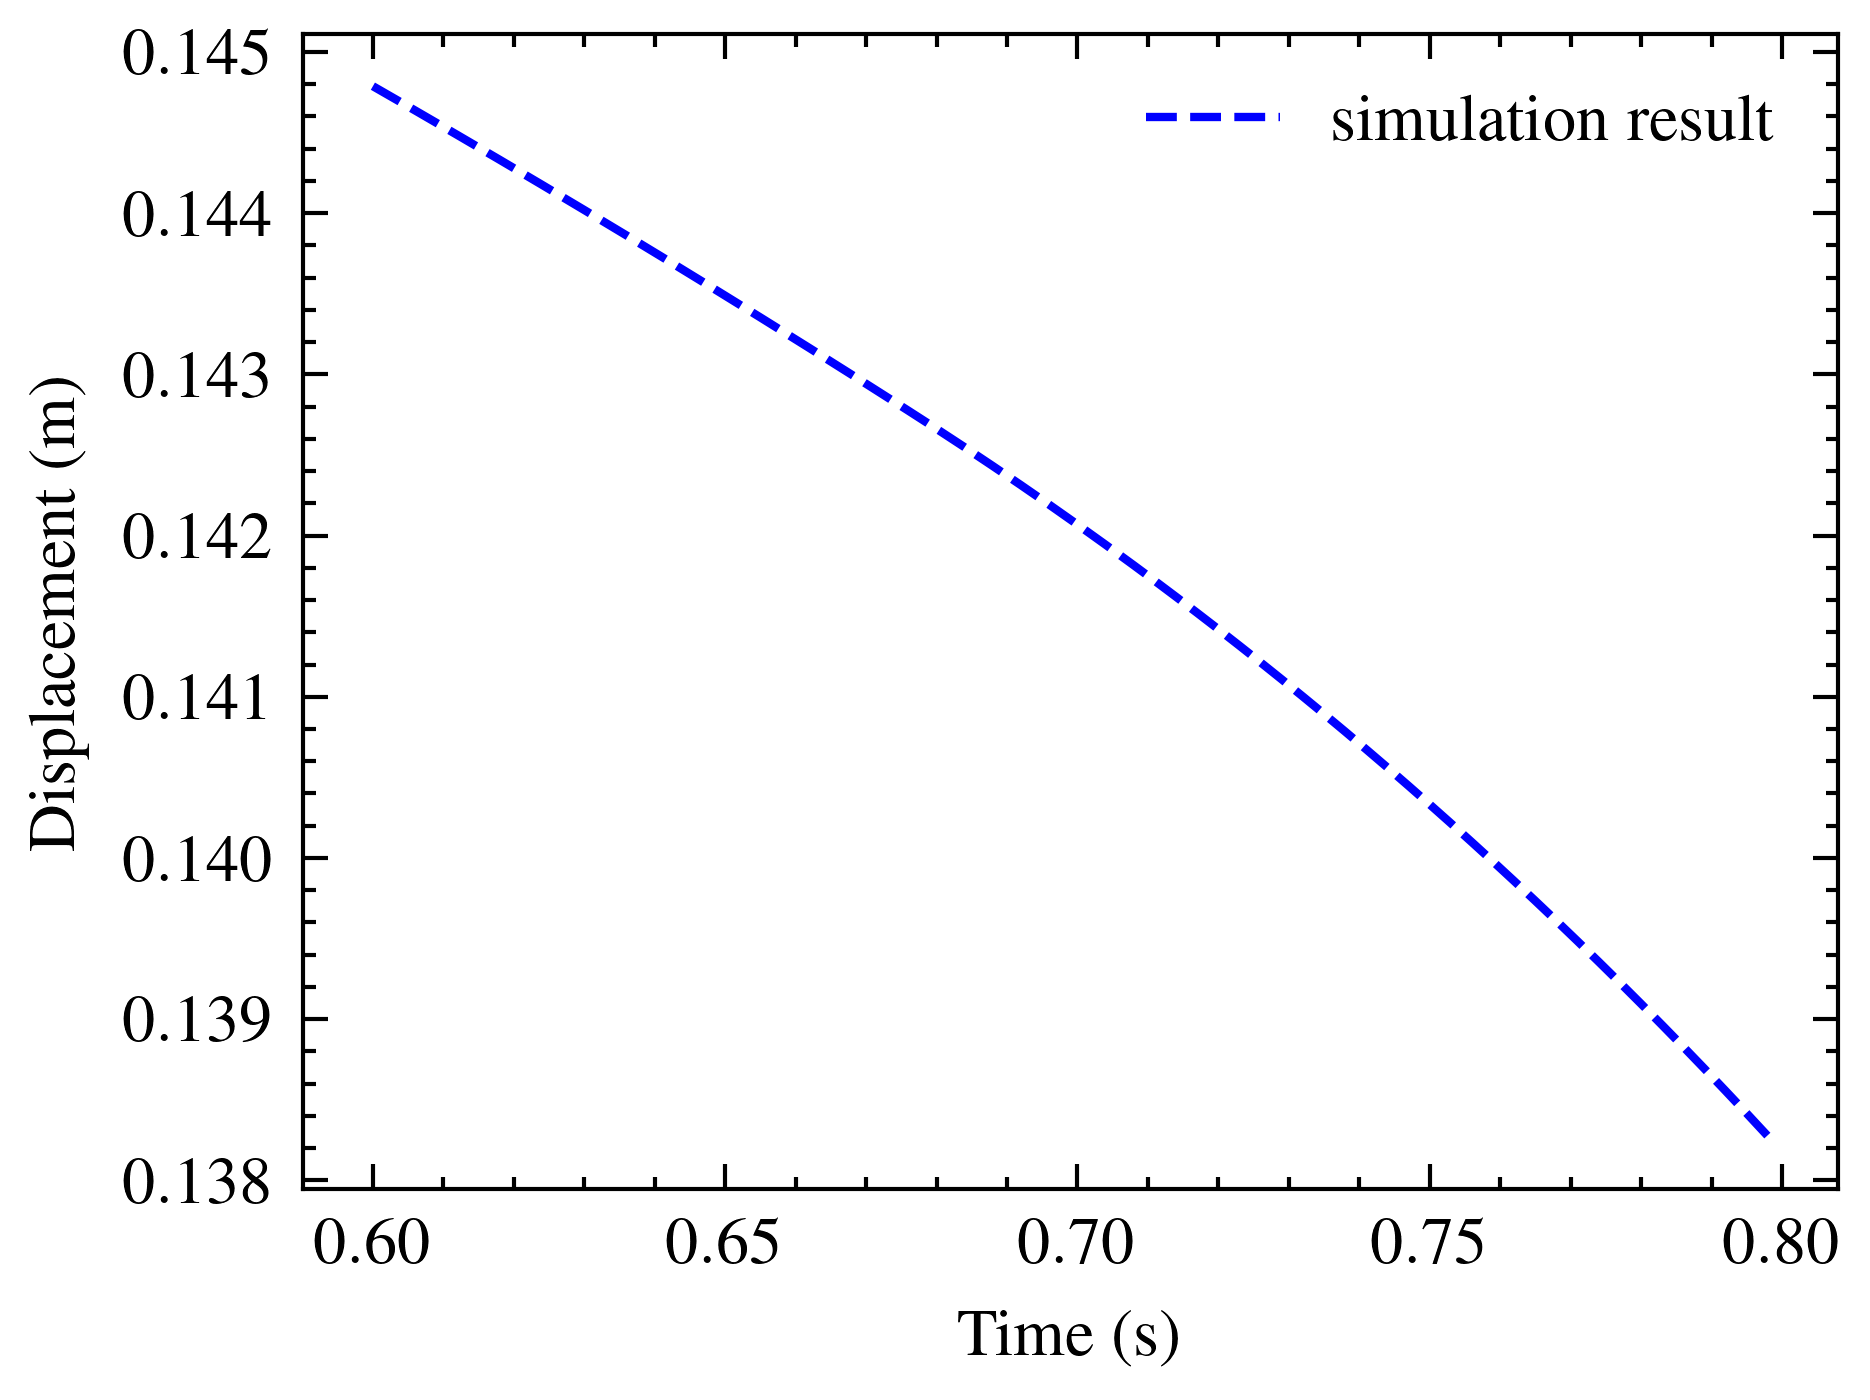

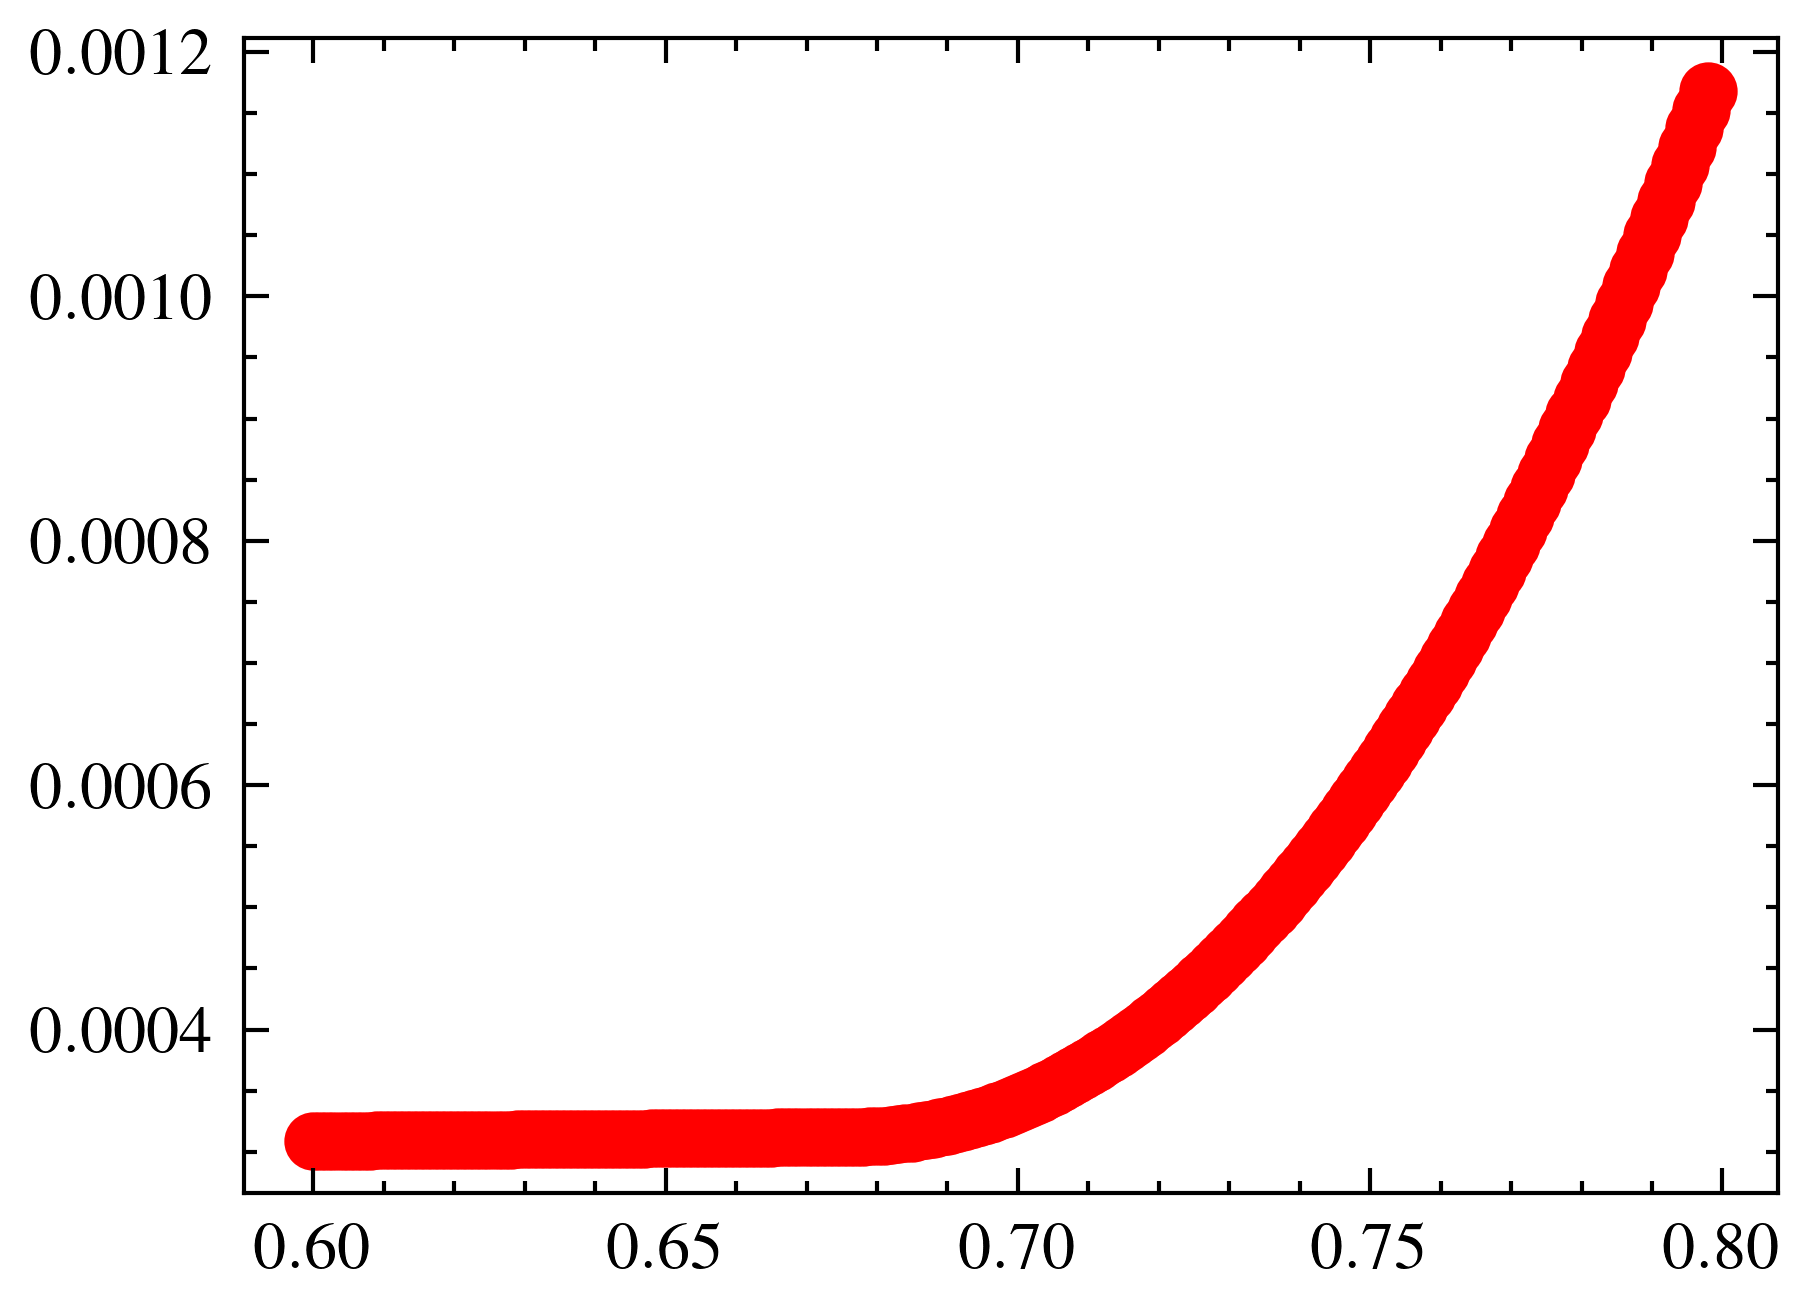

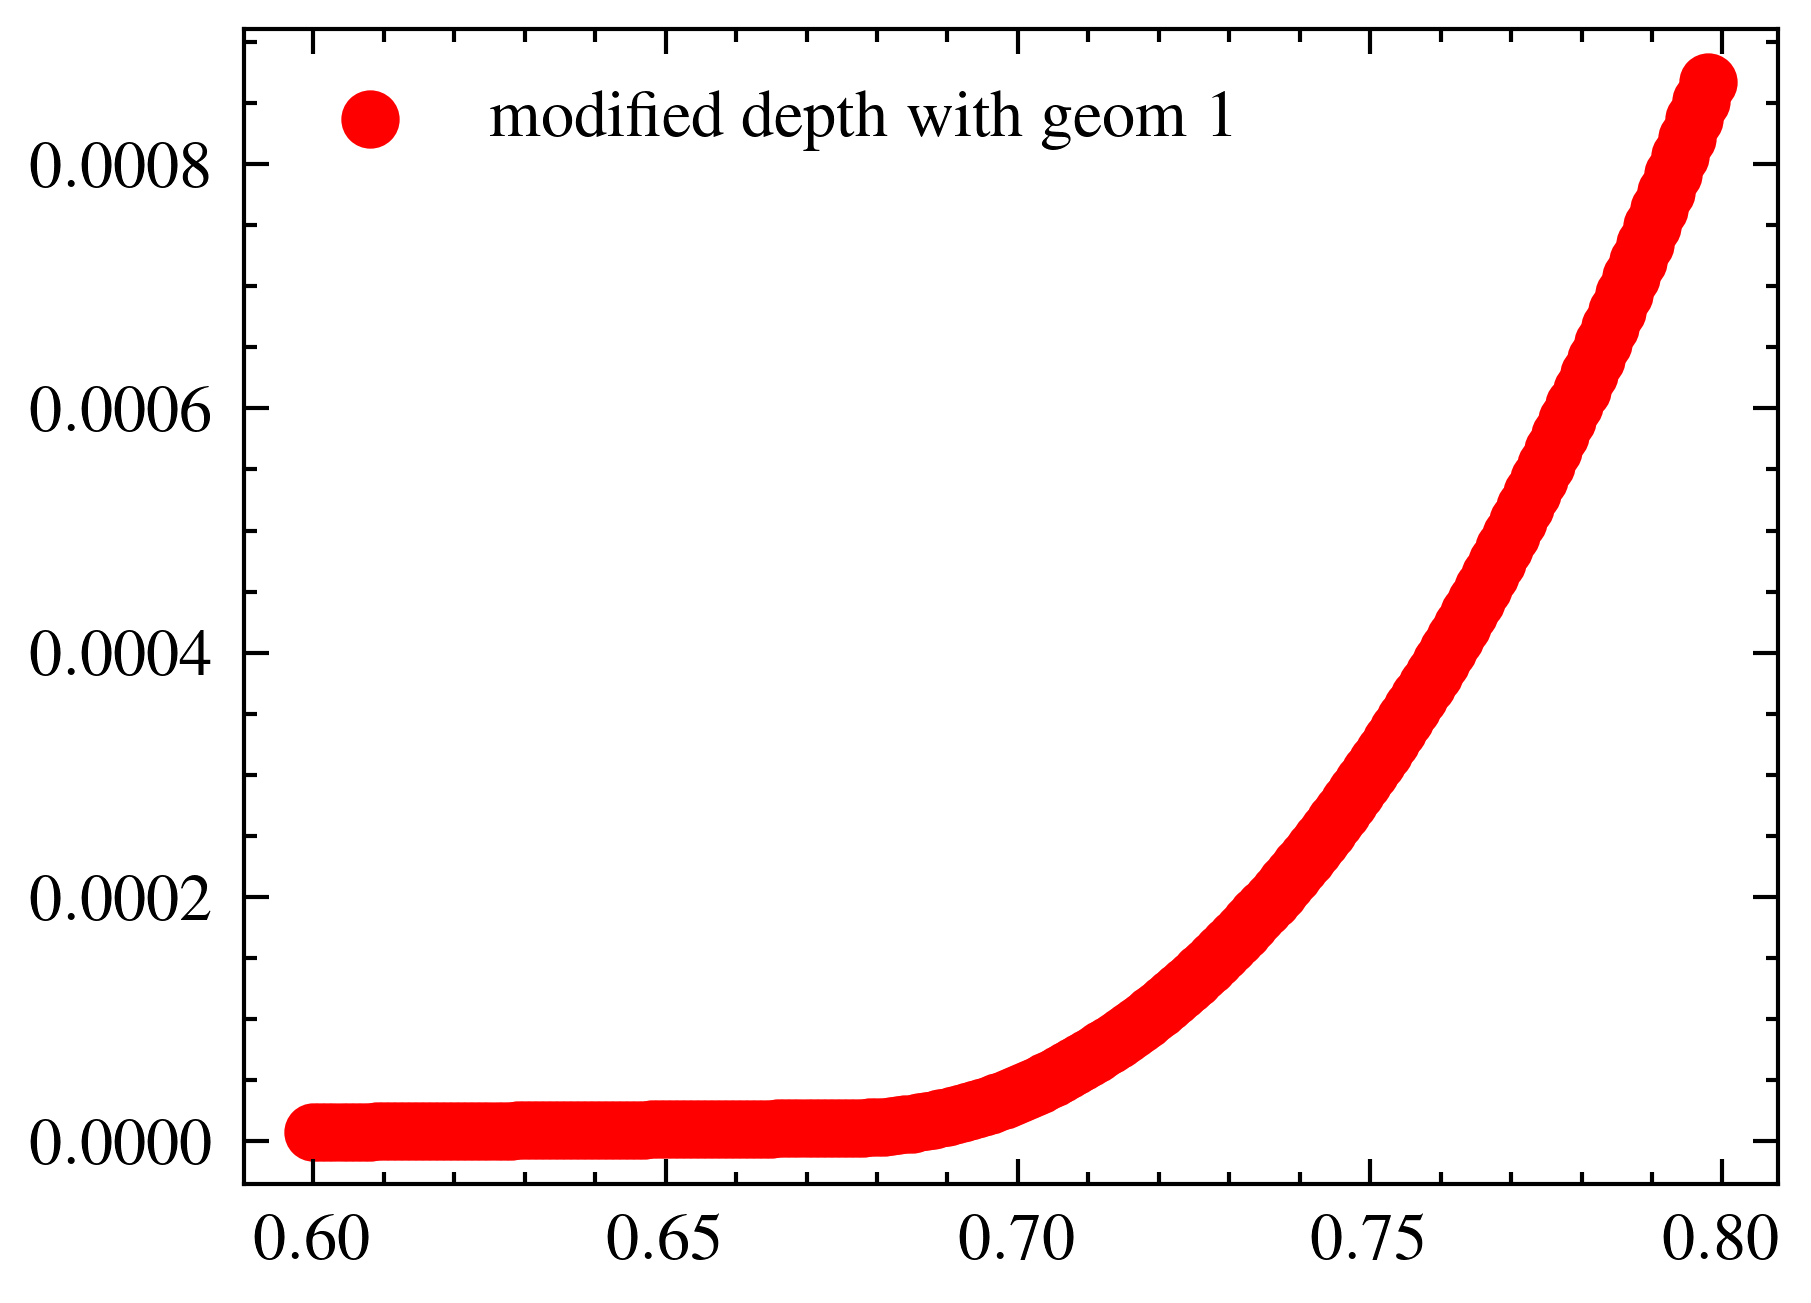

In [5]:
import json
import numpy as np
import sire
import matplotlib.pyplot as plt
import math
import scienceplots

# 查看顶层 keys
print(result.keys())

# result 写入文件
with open('result.json', 'w') as f:
    json.dump(result, f)

timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
penetrationPairs = result["penetrationPairs"]
dts = result["dts"]
x = []
y = []
t1 = []
c1 = []
modifiedDepthRecord = []
yv = []
start = 0.6
end = 0.8

lowerBound = sire.binarySearch(timeIndices, start)
upperBound = sire.binarySearch(timeIndices, end)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound-1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  if partpq[i] is not None:
    x.append(timeIndices[i])
    pm = sire.pq2tfmatrix(partpq[i][1])
    yOffset = pm[1, 3]
    zOffset = pm[2, 3]
    y.append(zOffset)  # z position from transformation matrix
  
  if penetrationPairs[i] is not None:
    for pair in penetrationPairs[i]:
        t1.append(timeIndices[i])
        c1.append(pair["depth"])
        modifiedDepthRecord.append(pair["modifiedDepth"])

  # yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

with plt.style.context(['science','ieee']):
  # plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  plt.show()
  # plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  # plt.xlabel("Time (s)")
  # plt.ylabel("Velocity (m/s)")
  # plt.legend()
  # plt.show()
  plt.scatter(t1, c1, color='red', label="contact with geom 1")
  plt.show() 

  plt.scatter(t1, modifiedDepthRecord, color='red', label="modified depth with geom 1")
  plt.legend()
  plt.show()

In [9]:
# Cell: print penetration pair keys to see available fields
penetrationPairs = result["penetrationPairs"]
for pp in penetrationPairs:
    if pp is not None and len(pp) > 0:
        print("penetration pair keys:", pp[0].keys())
        print("sample pair:", pp[0])
        break

penetration pair keys: dict_keys(['depth', 'geomIdA', 'geomIdB', 'modifiedDepth', 'nhat_AB_W', 'p_WC', 'p_WCa', 'p_WCb'])
sample pair: {'depth': 0.0003042673672197377, 'geomIdA': 0, 'geomIdB': 1, 'modifiedDepth': 0.0, 'nhat_AB_W': [-0.11032879263526034, 0.3861504248680685, -0.915814067859768], 'p_WC': [6.9945003450938685, 7.019248774756841, 0.10586752277465433], 'p_WCa': [6.994483560368237, 7.0193075212434035, 0.10572819660700908], 'p_WCb': [6.994517129819501, 7.019190028270278, 0.10600684894229957]}


result keys: ['contactInfo', 'contactPairResults', 'dts', 'generalForces', 'partAs', 'partPq', 'partVs', 'penetrationPairs', 'singleComponentForces', 'timeIndex']
0.6000000000000002 0.6010000000000002
Force Z: min=-30.2 N  max=-9.4 N
Force mag: min=9.4 N  max=31.8 N


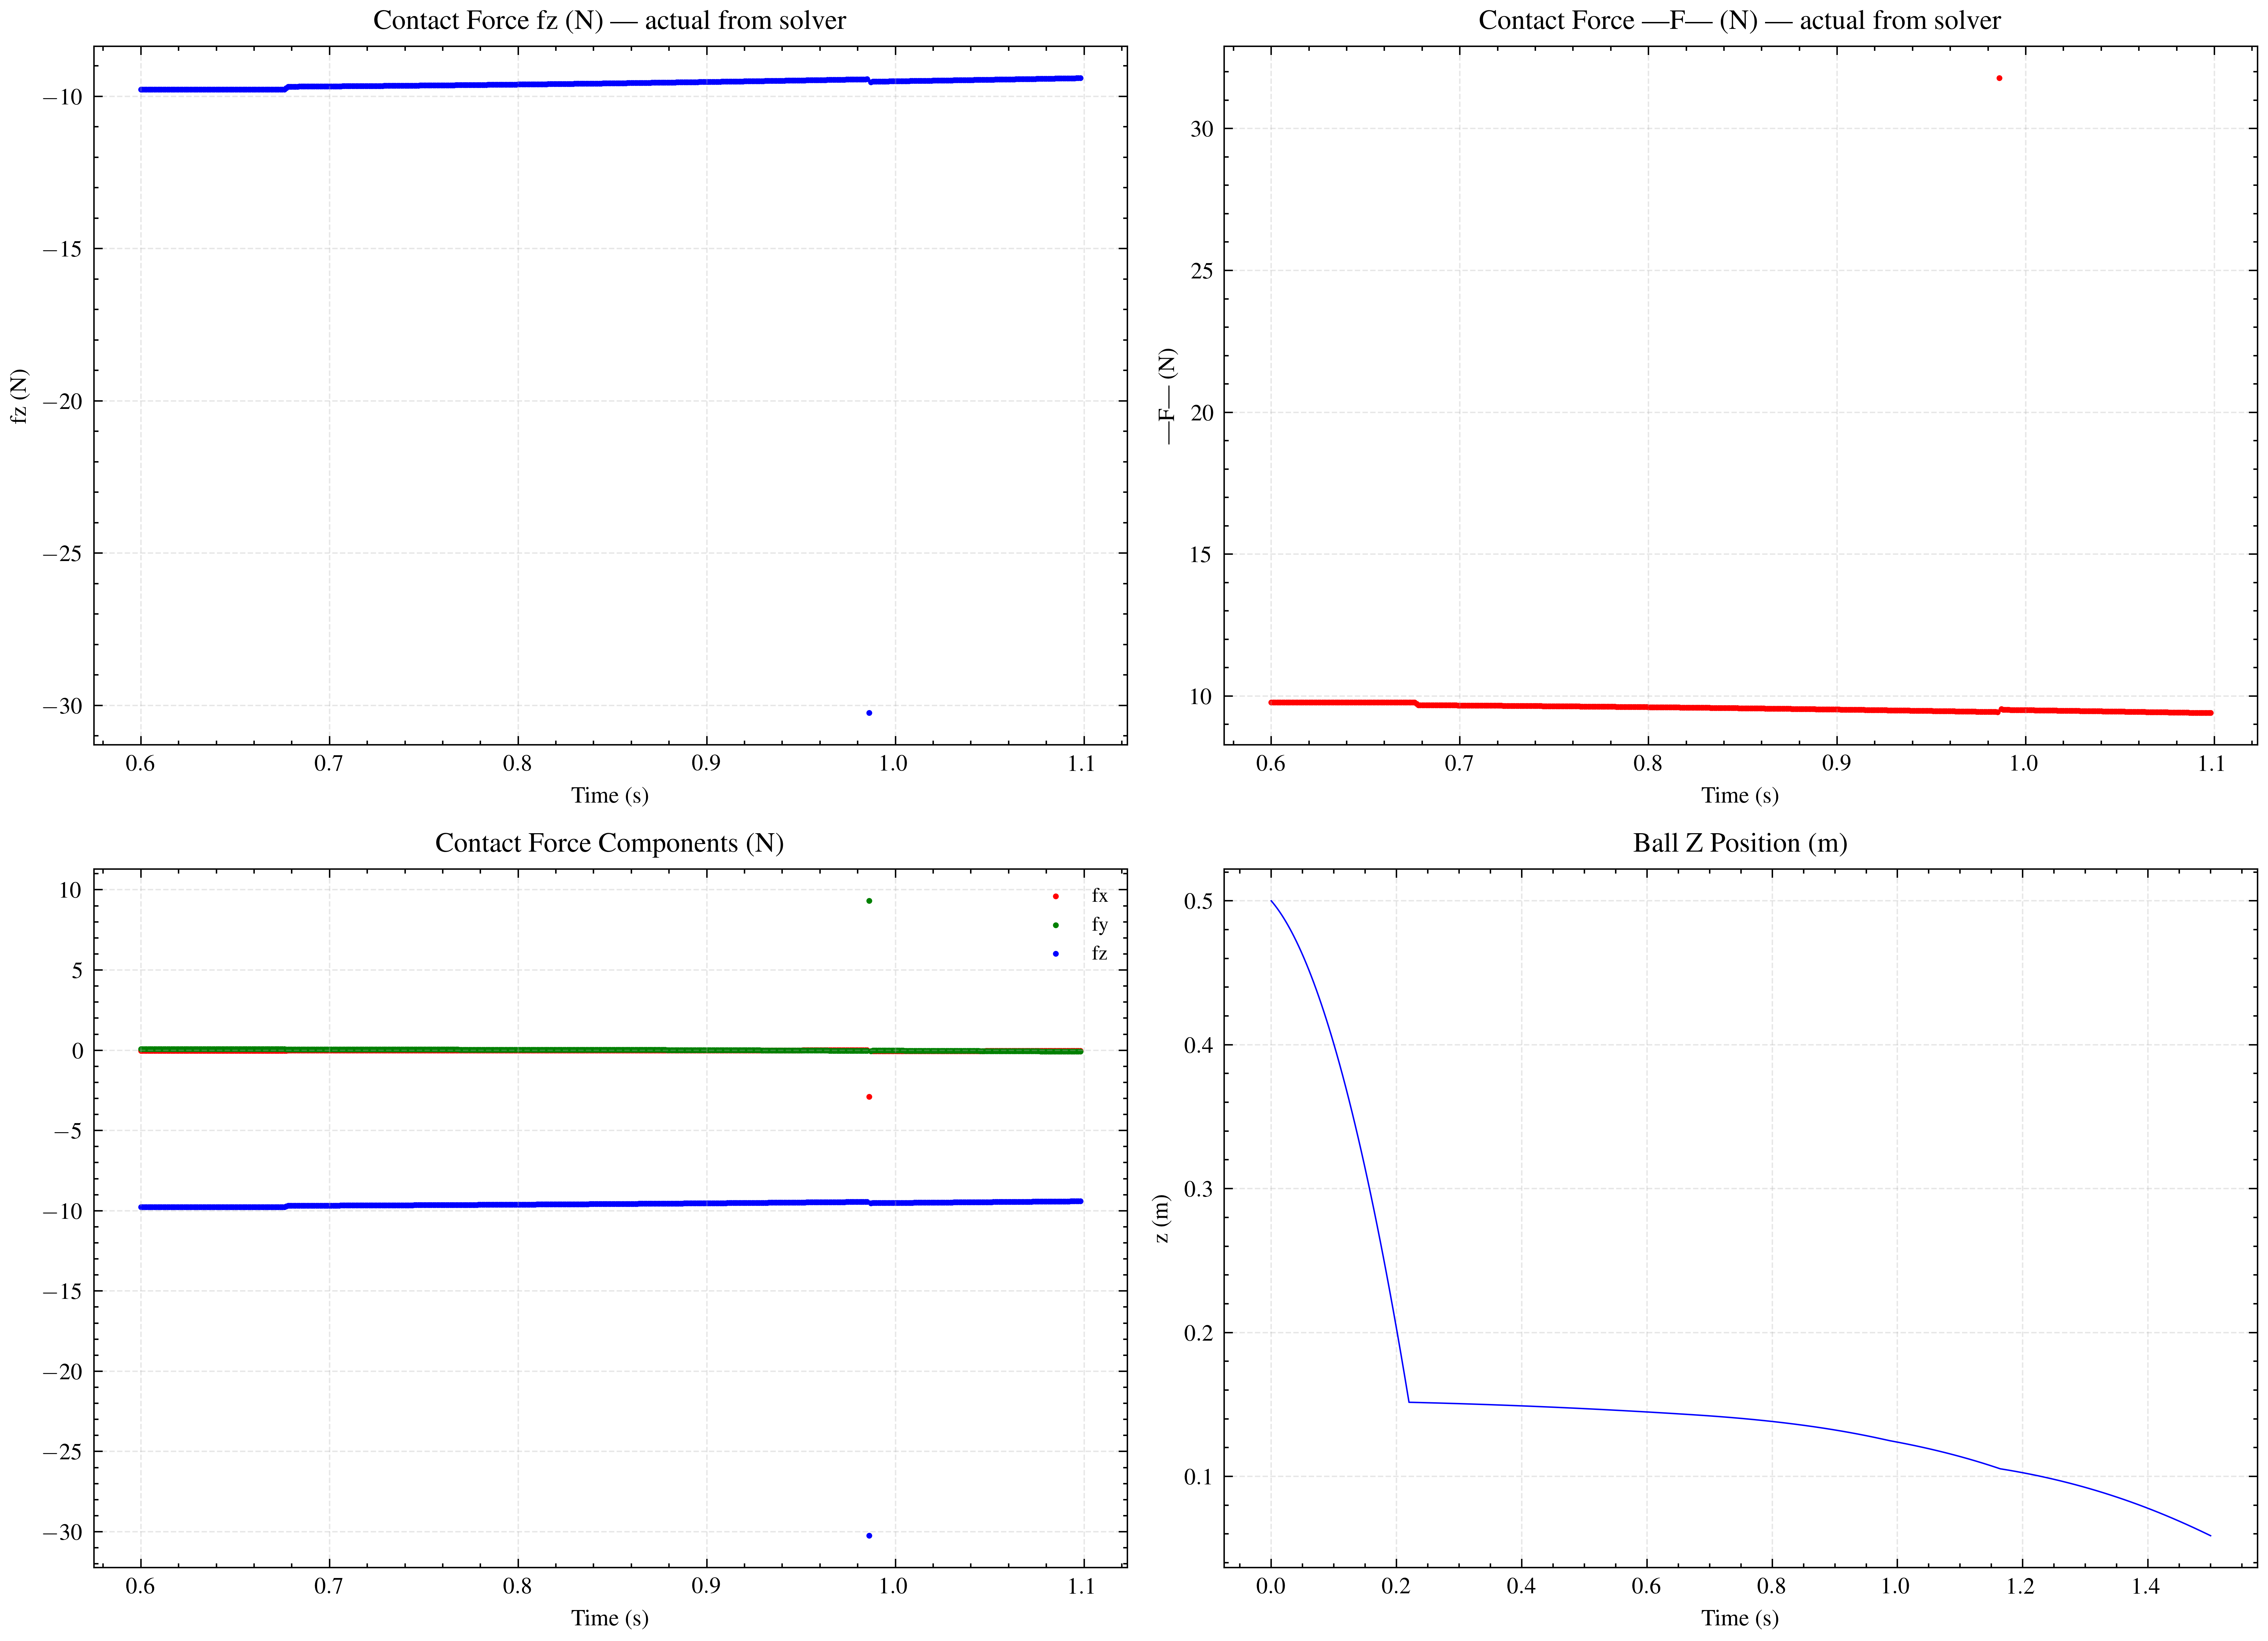

In [8]:
# Plot ACTUAL contact forces from recorded contactPairResults
# Re-run Cell 1 (simulation) first to get updated result with contactPairResults

print("result keys:", list(result.keys()))
if 'contactPairResults' in result:
    t_f = []; f_x = []; f_y = []; f_z = []; f_mag = []
    p_x = []; p_y = []; p_z = []

    start = 0.6
    end = 1.1

    lowerBound = sire.binarySearch(timeIndices, start)
    upperBound = sire.binarySearch(timeIndices, end)
    print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
    for i in range(lowerBound, upperBound-1):
        cpr = result['contactPairResults'][i]
        if cpr is not None:
            for pair in cpr:
                # pair keys: partIdA, partIdB, force_W, point_W
                t_f.append(timeIndices[i])
                fw = pair['force_W']
                f_x.append(fw[0]); f_y.append(fw[1]); f_z.append(fw[2])
                f_mag.append(np.sqrt(fw[0]**2 + fw[1]**2 + fw[2]**2))
                pw = pair['point_W']
                p_x.append(pw[0]); p_y.append(pw[1]); p_z.append(pw[2])
    
    print(f"Force Z: min={min(f_z):.1f} N  max={max(f_z):.1f} N")
    print(f"Force mag: min={min(f_mag):.1f} N  max={max(f_mag):.1f} N")
    
    with plt.style.context(['science','ieee']):
        fig, axes = plt.subplots(2, 2, figsize=(11, 8))
        
        # Force Z
        ax = axes[0,0]
        ax.scatter(t_f, f_z, s=1, color='b')
        ax.set_title('Contact Force fz (N) — actual from solver')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('fz (N)')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Force magnitude
        ax = axes[0,1]
        ax.scatter(t_f, f_mag, s=1, color='r')
        ax.set_title('Contact Force |F| (N) — actual from solver')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('|F| (N)')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Force components
        ax = axes[1,0]
        ax.scatter(t_f, f_x, s=1, color='r', label='fx')
        ax.scatter(t_f, f_y, s=1, color='g', label='fy')
        ax.scatter(t_f, f_z, s=1, color='b', label='fz')
        ax.set_title('Contact Force Components (N)')
        ax.set_xlabel('Time (s)'); ax.legend(fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Ball z
        ax = axes[1,1]
        z_ball = []; t_ball = []
        for i in range(len(timeIndices)):
            if partpq[i] is not None:
                t_ball.append(timeIndices[i])
                z_ball.append(partpq[i][1][2])
        ax.plot(t_ball, z_ball, 'b-', linewidth=0.5)
        ax.set_title('Ball Z Position (m)')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('z (m)')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("contactPairResults not in result — re-run Cell 1 (simulation) after 'pip install -e .'")

  Plotting 25 contact pairs  (t=0.6-1.1s, stride=20)


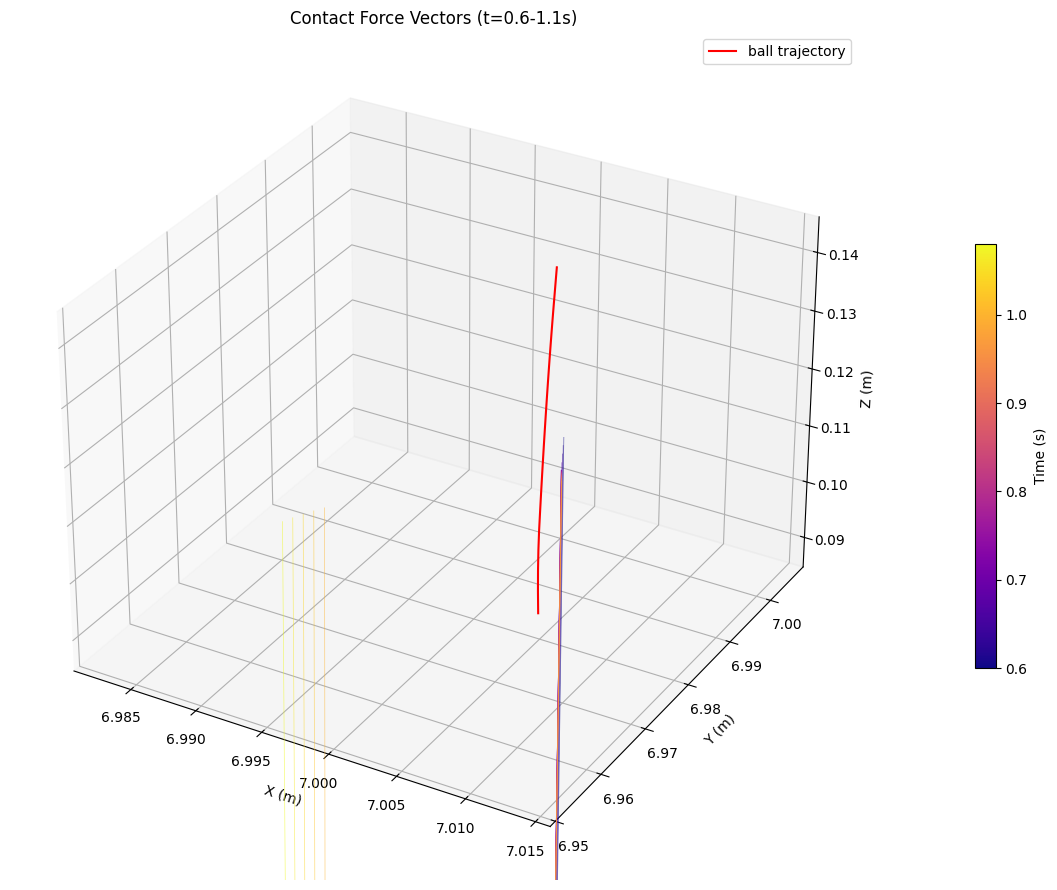

In [5]:
# 3D plot: contact force vectors on HeightField
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# ═══ tuning knobs ═══
start_time = 0.6    # plot from this time (s)
end_time   = 1.1    # plot to this time (s)
stride     = 20     # plot every Nth contact pair (1=all, higher=sparser)
timeIndices = result['timeIndex']
partpq = result["partPq"]
if 'contactPairResults' in result:
    p3d = []; f3d = []; mag3d = []; t3d = []

    lower = sire.binarySearch(timeIndices, start_time)
    upper = sire.binarySearch(timeIndices, end_time)

    for i in range(lower, upper):
        cpr = result['contactPairResults'][i]
        if cpr is not None:
            for pair in cpr:
                pw = pair['point_W']
                fw = pair['force_W']
                mag = np.sqrt(fw[0]**2 + fw[1]**2 + fw[2]**2)
                p3d.append(pw)
                f3d.append(fw)
                mag3d.append(mag)
                t3d.append(timeIndices[i])

    # Apply stride
    p3d   = np.array(p3d)[::stride]
    f3d   = np.array(f3d)[::stride]
    mag3d = np.array(mag3d)[::stride]
    t3d_s = np.array(t3d)[::stride]

    print(f"  Plotting {len(p3d)} contact pairs  "
          f"(t={start_time}-{end_time}s, stride={stride})")

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Color map from time
    norm = plt.Normalize(t3d_s.min(), t3d_s.max())
    colors = plt.cm.plasma(norm(t3d_s))

    # Arrow: direction = force, length proportional to magnitude
    mag_max = mag3d.max() if len(mag3d) > 0 else 1
    arrow_scale = 0.5 / mag_max if mag_max > 1e-6 else 1
    fx_n = np.where(mag3d > 0, f3d[:,0] / mag3d, 0)
    fy_n = np.where(mag3d > 0, f3d[:,1] / mag3d, 0)
    fz_n = np.where(mag3d > 0, f3d[:,2] / mag3d, 0)
    arrow_len = mag3d * arrow_scale

    ax.quiver(p3d[:,0], p3d[:,1], p3d[:,2],
              fx_n * arrow_len, fy_n * arrow_len, fz_n * arrow_len,
              color=colors, alpha=0.6, linewidth=0.5)

    # HeightField surface
    from PIL import Image
    try:
        png_path = r"C:\Users\leiti\AppData\Local\Temp\mujoco_rl_terrain\terrain_hf_60q_l210.png"
        img = Image.open(png_path).convert('L')
        hf = np.array(img, dtype=np.float64) / 255.0 * 0.2 - 0.02
        s = 8
        hf_ds = hf[::s, ::s]
        ny, nx = hf_ds.shape
        xs_ds = np.linspace(2, 12, nx)
        ys_ds = np.linspace(2, 12, ny)
        xs_m, ys_m = np.meshgrid(xs_ds, ys_ds)
        ax.plot_surface(xs_m, ys_m, hf_ds, alpha=0.3, color='lightgreen', edgecolor='none')
    except Exception as e:
        print(f"  Terrain surface error: {e}")

    # Ball trajectory (also clipped to time range)
    bx = []; by = []; bz = []
    for i in range(lower, upper):
        if partpq[i] is not None:
            bx.append(partpq[i][1][0])
            by.append(partpq[i][1][1])
            bz.append(partpq[i][1][2])
    ax.plot(bx[::stride], by[::stride], bz[::stride], 'r-', linewidth=1.5, label='ball trajectory')

    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title(f'Contact Force Vectors (t={start_time}-{end_time}s)')

    sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label('Time (s)')

    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("contactPairResults not available — re-run Cell 1 first")

In [5]:
# Interactive 3D plot with plotly — force vectors as line segments
import plotly.graph_objects as go
import matplotlib.pyplot as plt

timeIndices = result['timeIndex']
partpq = result["partPq"]
start_time = 0.6
end_time   = 2
stride     = 5   # lower = more arrows

if 'contactPairResults' in result:
    lower = sire.binarySearch(timeIndices, start_time)
    upper = sire.binarySearch(timeIndices, end_time)

    px=[]; py=[]; pz=[]; fx=[]; fy=[]; fz=[]; mag=[]; t_val=[]
    for i in range(lower, upper):
        cpr = result['contactPairResults'][i]
        if cpr is not None:
            for pair in cpr:
                negative = 1
                if pair['partIdB'] == 0:
                    negative = -1
                pw = pair['point_W']; fw = pair['force_W']
                px.append(pw[0]); py.append(pw[1]); pz.append(pw[2])
                fx.append(negative * fw[0]); fy.append(negative * fw[1]); fz.append(negative * fw[2])
                mag.append(np.sqrt(fw[0]**2 + fw[1]**2 + fw[2]**2))
                t_val.append(timeIndices[i])
    px=np.array(px)[::stride]; py=np.array(py)[::stride]; pz=np.array(pz)[::stride]
    fx=np.array(fx)[::stride]; fy=np.array(fy)[::stride]; fz=np.array(fz)[::stride]
    mag=np.array(mag)[::stride]; t_arr=np.array(t_val)[::stride]

    print(f"Plotting {len(px)} arrows, force min={mag.min():.4f} N max={mag.max():.4f} N")

    # Scale: max force → 0.02 m arrow (fitting ball trajectory scale)
    scale = 0.1 / (mag.max() if mag.max() > 1e-6 else 1)
    ux = fx * scale; uy = fy * scale; uz = fz * scale
    # Tip points
    tx = px + ux; ty = py + uy; tz = pz + uz

    # Build line segments: [p0, tip0, None, p1, tip1, None, ...]
    xs=[]; ys=[]; zs=[]
    for k in range(len(px)):
        xs.extend([px[k], tx[k], None])
        ys.extend([py[k], ty[k], None])
        zs.extend([pz[k], tz[k], None])

    fig = go.Figure()

    # Ball trajectory
    bx = []; by = []; bz = []
    for i in range(lower, upper):
        if partpq[i] is not None:
            bx.append(partpq[i][1][0])
            by.append(partpq[i][1][1])
            bz.append(partpq[i][1][2])
    bx=bx[::stride]; by=by[::stride]; bz=bz[::stride]
    fig.add_trace(go.Scatter3d(
        x=bx, y=by, z=bz, mode='lines',
        line=dict(color='red', width=4), name='Ball trajectory'))

    # Force arrows as line segments, colored by time
    # Split into groups by time for color (use scatter with marker colors)
    norm = plt.Normalize(t_arr.min(), t_arr.max())
    for k in range(len(px)):
        c = f"rgb({int(255*norm(t_arr[k]))},0,{255-int(255*norm(t_arr[k]))})"
        fig.add_trace(go.Scatter3d(
            x=[px[k], tx[k]], y=[py[k], ty[k]], z=[pz[k], tz[k]],
            mode='lines+markers',
            line=dict(color=c, width=2),
            marker=dict(size=2, color=c),
            showlegend=False))

    fig.update_layout(
        title=f'Contact Forces on HeightField (t={start_time}-{end_time}s, {len(px)} arrows)',
        scene=dict(
            xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
            aspectmode='data'),
        width=900, height=700)
    fig.show()
else:
    print("contactPairResults not available — re-run Cell 1 first")

Plotting 181 arrows, force min=9.3384 N max=9.7721 N
